# Malware Package Classifier - End-to-End Analysis

This notebook builds and evaluates a malware detection classifier using static package features.

Workflow:
1. Data loading and quality checks
2. Feature engineering and leakage diagnostics
3. Baseline Random Forest
4. Hyperparameter tuning with stratified CV
5. Probability calibration and threshold optimization
6. Final model and threshold export

## 1) Load Libraries and Helper Functions

We define a reusable evaluation helper to keep model comparisons consistent (accuracy, malware precision/recall/F1, and PR-AUC).

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    make_scorer,
 )

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'malware_precision': precision_score(y_true, y_pred, pos_label=1),
        'malware_recall': recall_score(y_true, y_pred, pos_label=1),
        'malware_f1': f1_score(y_true, y_pred, pos_label=1),
        'pr_auc': average_precision_score(y_true, y_prob),
        'y_pred': y_pred,
    }

print("Libraries and helpers loaded successfully!")

Libraries and helpers loaded successfully!


In [67]:
df = pd.read_csv('dataset.csv').copy()

# Package-family key helps us estimate leakage from version-level overlap.
df['package_family'] = df['package_name'].str.replace(r'-(\d+(?:\.\d+)*.*)$', '', regex=True)

print(f"Rows: {len(df):,}")
print(f"Benign: {(df['label'] == 0).sum():,}")
print(f"Malware: {(df['label'] == 1).sum():,}")
print(f"Malware ratio: {(df['label'] == 1).mean() * 100:.2f}%")

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])
display(df.head())

Rows: 35,362
Benign: 13,784
Malware: 21,578
Malware ratio: 61.02%


Series([], dtype: int64)

,package_name,ecosystem,max_entropy,avg_entropy,eval_count,exec_count,base64_count,network_imports,label,package_family
0,3net.js-0.2.4,NPM,5.101039,4.725404,0,0,0,0,0,3net.js
1,4search-0.0.1,NPM,5.413635,4.760083,0,0,0,0,0,4search
2,a-driver.js-0.9.8-shadowdom2,NPM,5.419901,4.773957,0,0,0,0,0,a-driver.js
3,a-frame-router-templates-0.0.4,NPM,7.943876,5.432943,0,0,0,0,0,a-frame-router-templates
4,acc-calc-1.0.2,NPM,5.479960,4.919122,0,0,0,0,0,acc-calc


## 3) Feature Engineering and Split Strategy

We engineer ratio-based features and perform a stratified split. We also quantify overlap between train and test package families to estimate leakage risk.

In [68]:
X = df.drop(columns=['package_name', 'ecosystem', 'label', 'package_family']).copy()
y = df['label'].copy()

# Feature engineering from available static signals.
X['entropy_gap'] = X['max_entropy'] - X['avg_entropy']
X['exec_eval_ratio'] = (X['exec_count'] + 1) / (X['eval_count'] + 1)
X['network_exec_ratio'] = (X['network_imports'] + 1) / (X['exec_count'] + 1)
X['obfuscation_index'] = X['entropy_gap'] * np.log1p(X['base64_count'])

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    df[['package_name', 'package_family']],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
 )

duplicate_rows = int(X.duplicated().sum())
family_overlap = set(meta_train['package_family']).intersection(set(meta_test['package_family']))
family_overlap_ratio = (len(family_overlap) / max(1, meta_test['package_family'].nunique())) * 100

print(f"Training on {len(X_train):,} packages | Testing on {len(X_test):,} packages")
print(f"Duplicate feature rows in dataset: {duplicate_rows}")
print(f"Train/Test package-family overlap: {len(family_overlap):,} ({family_overlap_ratio:.2f}% of test families)")
print(f"Feature columns: {list(X.columns)}")

Training on 28,289 packages | Testing on 7,073 packages
Duplicate feature rows in dataset: 125
Train/Test package-family overlap: 1,364 (23.55% of test families)
Feature columns: ['max_entropy', 'avg_entropy', 'eval_count', 'exec_count', 'base64_count', 'network_imports', 'entropy_gap', 'exec_eval_ratio', 'network_exec_ratio', 'obfuscation_index']


## 4) Baseline Model and Diagnostics

A baseline Random Forest gives a reference point before tuning. We analyze both confusion matrix and precision-recall behavior.

In [69]:
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
 )

baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_results = evaluate_predictions(y_test, baseline_proba, threshold=0.5)

print("Baseline Random Forest training complete!")

Baseline Random Forest training complete!


In [70]:
print("Baseline model report (threshold = 0.50):")
print(f"Accuracy: {baseline_results['accuracy'] * 100:.2f}%")
print(f"Malware Precision: {baseline_results['malware_precision']:.4f}")
print(f"Malware Recall: {baseline_results['malware_recall']:.4f}")
print(f"Malware F1: {baseline_results['malware_f1']:.4f}")
print(f"PR-AUC: {baseline_results['pr_auc']:.4f}\n")

print(classification_report(
    y_test,
    baseline_results['y_pred'],
    target_names=['Benign (0)', 'Malware (1)']
))

Baseline model report (threshold = 0.50):
Accuracy: 93.36%
Malware Precision: 0.9349
Malware Recall: 0.9578
Malware F1: 0.9462
PR-AUC: 0.9822

              precision    recall  f1-score   support

  Benign (0)       0.93      0.90      0.91      2757
 Malware (1)       0.93      0.96      0.95      4316

    accuracy                           0.93      7073
   macro avg       0.93      0.93      0.93      7073
weighted avg       0.93      0.93      0.93      7073



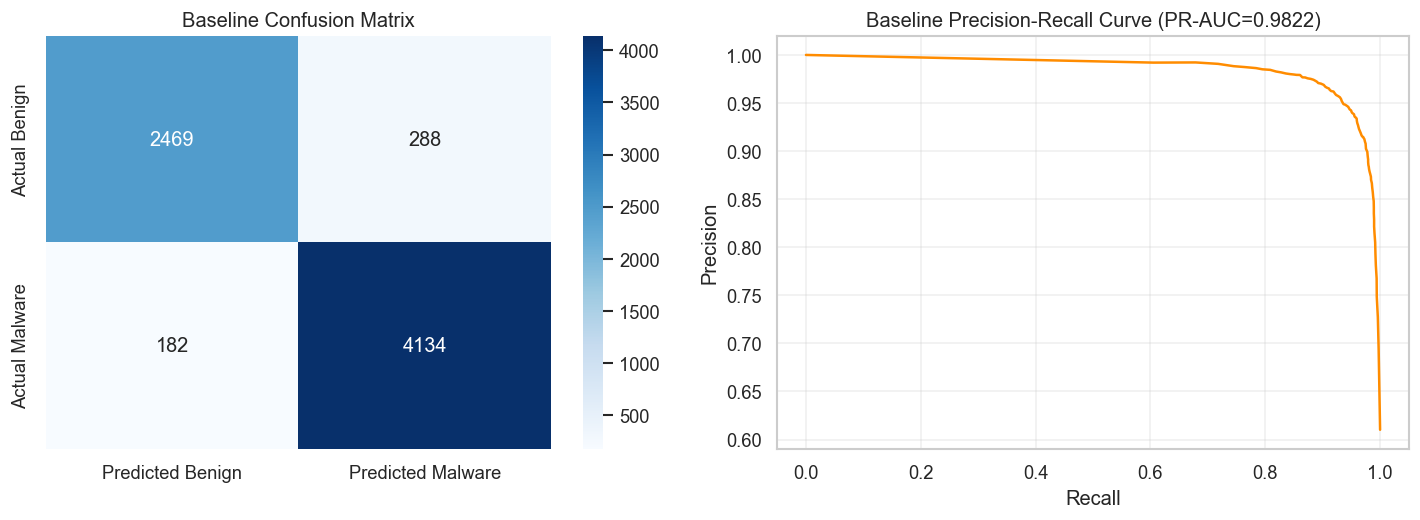

In [71]:
cm = confusion_matrix(y_test, baseline_results['y_pred'])
precision_curve, recall_curve, _ = precision_recall_curve(y_test, baseline_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Benign', 'Predicted Malware'],
    yticklabels=['Actual Benign', 'Actual Malware'],
    ax=axes[0],
 )
axes[0].set_title('Baseline Confusion Matrix')

axes[1].plot(recall_curve, precision_curve, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f"Baseline Precision-Recall Curve (PR-AUC={baseline_results['pr_auc']:.4f})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

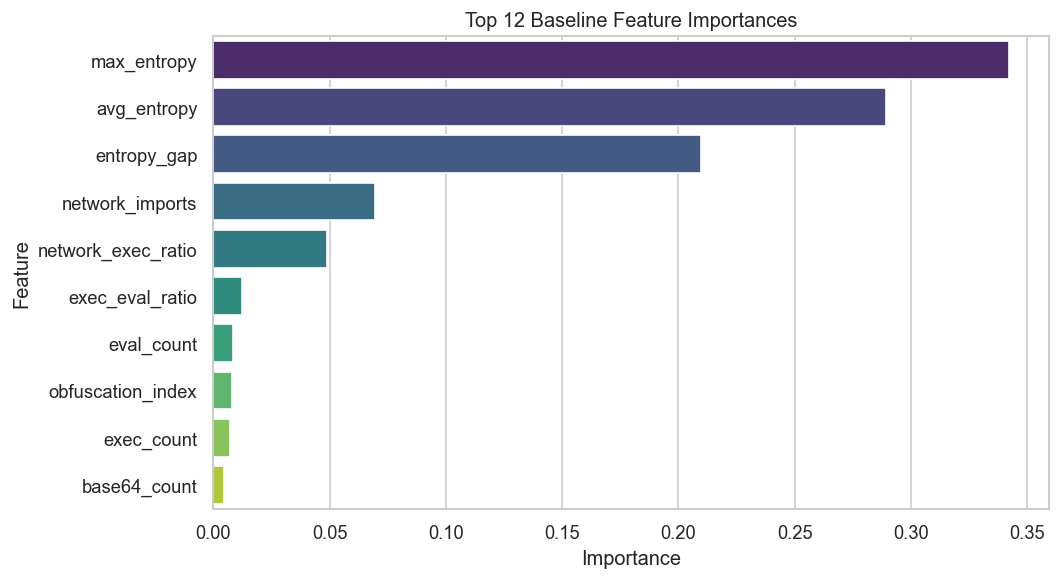

,Feature,Importance
0,max_entropy,0.342150
1,avg_entropy,0.289438
2,entropy_gap,0.209695
3,network_imports,0.069349
4,network_exec_ratio,0.048775
5,exec_eval_ratio,0.012191
6,eval_count,0.008391
7,obfuscation_index,0.008129
8,exec_count,0.007144
9,base64_count,0.004737


In [72]:
importances = baseline_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
top_features = feature_df.head(12)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    dodge=False,
    palette='viridis',
    legend=False,
 )
plt.title('Top 12 Baseline Feature Importances')
plt.tight_layout()
plt.show()

display(top_features)

## 5) Tuned, Calibrated Production Model

We optimize for Malware F1 with stratified cross-validation, calibrate probabilities, tune decision threshold, compare baseline vs tuned metrics, and save artifacts.

In [73]:
joblib.dump(baseline_model, 'malware_classifier_baseline.pkl')
print("Baseline model saved as 'malware_classifier_baseline.pkl'.")

Baseline model saved as 'malware_classifier_baseline.pkl'.


Starting stratified Random Forest search for the best production model...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best hyperparameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}
Best CV Malware F1: 0.9413


,Model,Accuracy,Malware Precision,Malware Recall,Malware F1,PR-AUC
0,Baseline RF @ 0.50,0.9336,0.9349,0.9578,0.9462,0.9822
1,Tuned RF @ 0.486,0.9327,0.9356,0.9555,0.9454,0.9854


Optimal Malware Threshold: 0.486118


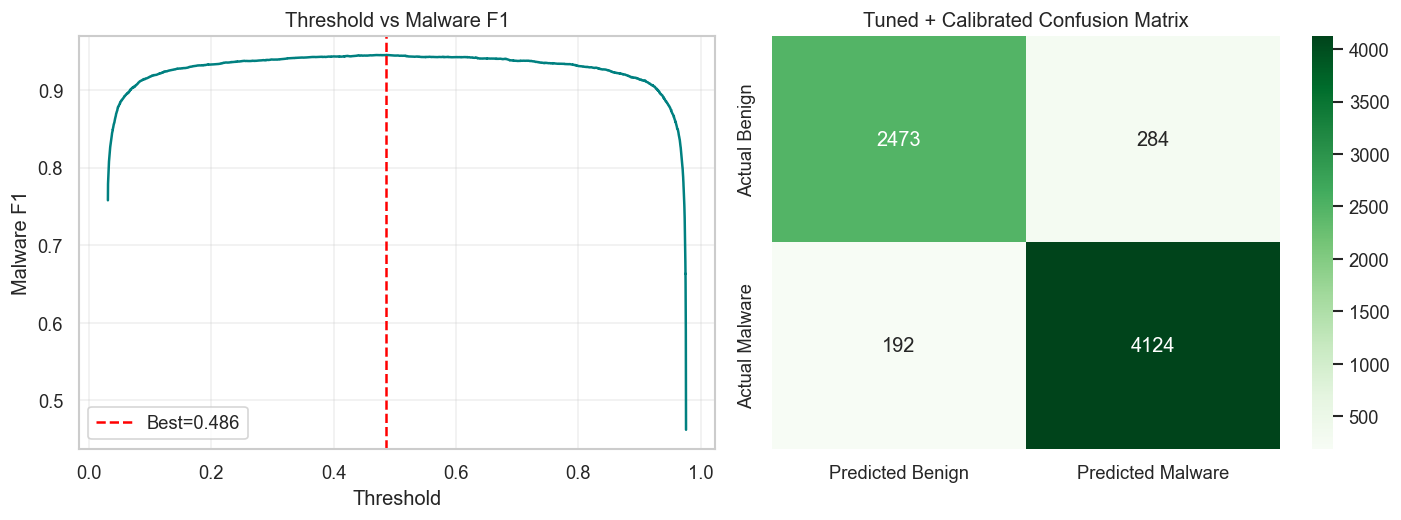

Saved best model to 'malware_classifier.pkl' and threshold to 'malware_threshold.pkl'.


In [74]:
print("Starting stratified Random Forest search for the best production model...")

param_distributions = {
    'n_estimators': [100, 200, 300, 400, 600],
    'max_depth': [None, 10, 20, 30, 40],
    'class_weight': ['balanced', None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring=make_scorer(f1_score, pos_label=1),
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
 )

search.fit(X_train, y_train)
best_model = search.best_estimator_
print(f"\nBest hyperparameters: {search.best_params_}")
print(f"Best CV Malware F1: {search.best_score_:.4f}")

# Calibrate predicted probabilities for better threshold decisions.
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated_model.fit(X_train, y_train)
tuned_proba = calibrated_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, tuned_proba)
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])

tuned_results = evaluate_predictions(y_test, tuned_proba, threshold=best_threshold)

comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline RF @ 0.50',
        'Accuracy': baseline_results['accuracy'],
        'Malware Precision': baseline_results['malware_precision'],
        'Malware Recall': baseline_results['malware_recall'],
        'Malware F1': baseline_results['malware_f1'],
        'PR-AUC': baseline_results['pr_auc'],
    },
    {
        'Model': f"Tuned RF @ {best_threshold:.3f}",
        'Accuracy': tuned_results['accuracy'],
        'Malware Precision': tuned_results['malware_precision'],
        'Malware Recall': tuned_results['malware_recall'],
        'Malware F1': tuned_results['malware_f1'],
        'PR-AUC': tuned_results['pr_auc'],
    },
])

display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Malware Precision': '{:.4f}',
    'Malware Recall': '{:.4f}',
    'Malware F1': '{:.4f}',
    'PR-AUC': '{:.4f}',
}))

print(f"Optimal Malware Threshold: {best_threshold:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(thresholds, f1_scores, color='teal')
axes[0].axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.3f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Malware F1')
axes[0].set_title('Threshold vs Malware F1')
axes[0].legend()
axes[0].grid(alpha=0.3)

tuned_cm = confusion_matrix(y_test, tuned_results['y_pred'])
sns.heatmap(
    tuned_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Benign', 'Predicted Malware'],
    yticklabels=['Actual Benign', 'Actual Malware'],
    ax=axes[1],
 )
axes[1].set_title('Tuned + Calibrated Confusion Matrix')

plt.tight_layout()
plt.show()

joblib.dump(calibrated_model, 'malware_classifier.pkl')
joblib.dump({'threshold': best_threshold}, 'malware_threshold.pkl')
print("Saved best model to 'malware_classifier.pkl' and threshold to 'malware_threshold.pkl'.")

In [75]:
# Final model selection: choose the better test-time performer.
if tuned_results['malware_f1'] > baseline_results['malware_f1']:
    production_model = calibrated_model
    production_threshold = best_threshold
    production_name = 'Tuned + Calibrated RF'
elif tuned_results['malware_f1'] < baseline_results['malware_f1']:
    production_model = baseline_model
    production_threshold = 0.5
    production_name = 'Baseline RF'
else:
    if tuned_results['pr_auc'] >= baseline_results['pr_auc']:
        production_model = calibrated_model
        production_threshold = best_threshold
        production_name = 'Tuned + Calibrated RF (tie-break by PR-AUC)'
    else:
        production_model = baseline_model
        production_threshold = 0.5
        production_name = 'Baseline RF (tie-break by PR-AUC)'

joblib.dump(production_model, 'malware_classifier.pkl')
joblib.dump({'threshold': float(production_threshold)}, 'malware_threshold.pkl')

print(f"Selected production model: {production_name}")
print(f"Production threshold: {production_threshold:.6f}")
print("Re-saved production artifacts: malware_classifier.pkl and malware_threshold.pkl")

Selected production model: Baseline RF
Production threshold: 0.500000
Re-saved production artifacts: malware_classifier.pkl and malware_threshold.pkl
